In [1]:
# En la primera celda de tu Notebook:
import numpy as np
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import osmnx as ox
import time
from lifelines import KaplanMeierFitter
import importlib

# Problem statement
Assigning ambulances to emergency calls is a challenging operational problem due to limited availability of resources such as ambulances hospitals capacity and time. In emergency response systems, reducing delays is critical because reponse times can directly affect patient outcomes. Stochastic simulations provide an effective framework for evaluating alternative dispatch strategies under realistic operating conditions through simulations, with relatively low data requirements. 

In this project studies an **Ambulance Assignment Problem** by comparing two dispatch policies:
1) **Greedy assignation policy (GP)**: assigns the closest available ambulance to each incoming emergency call, minimizing immediate travel time.
2) **Optimization assignation policy (OP)**: assigns ambulances by solving a global allocation problem at each timestep, aiming to minimize total travel time across assignments in the system.

## System Components
### Ambulances
Let

$$
\mathcal{A}={1,\ldots,K}
$$

denote the set of available ambulances, where $A$ represents the fleet size. 

Each ambulance can be in one of two states:

* Available
* Busy (serving a call or transporting a patient)

### Hospitals
Let

$$
\mathcal{H}={1,\ldots,H}
$$

denote the set of hospitals. 

Hospital locations correspond to real healthcare facilities located in Quebec City and are shown below
![Mapa de hospitales](./Photos/hospitals.png)

### Emergency Calls
Emergency calls are generated stochastically according to a Poisson process with emergency call rate (ECR):

$$
\lambda \quad \text{(calls/hour)}.
$$

Call locations are randomly generated within the study region.

The simulation horizon is fixed to

$$
T = 60 \text{ minutes},
$$

while the system state is updated every minute ($\Delta t=1\ min$).

## Dispatch Policies
In this case, response time is defined as the elapsed time between the arrival of an emergency call and the arrival of an assigned ambulance at the patient location. It includes both the delay until an ambulance becomes available for assignment (waiting time) and the subsequent travel time to the incident location.
$$
RT = WT + TT
$$
Where:
* RT: Response time
* WT: Waiting time
* TT: Travel time
### Greedy Policy (GP)
For an incoming call located at $c$, the greedy policy assigns the available ambulance that minimizes travel time to the call location:

$$
a^* =
\arg\min_{a \in \mathcal{A}_{\text{avail}}}
d(a,c),
$$

where $d(a,c)$ denotes the travel time from ambulance $a$ to call $c$. This policy is myopic since it only considers the immediate dispatch decision and does not account for other pending calls or future system states.

## Optimization Policy (OP)
The optimization policy considers all pending calls and all available ambulances each timestep simultaneously. A cost matrix is constructed using the travel time between each ambulance and call location. The optimal assignment is then obtained by solving a linear assignment problem using the Hungarian algorithm, minimizing the total travel time across all dispatches
$$
min \sum_{i,j} d(a_i,c_j)
$$

Unlike the greedy policy, which assign ambulances sequentially to incoming calls without explicitly optimizing over the full set of possible allocations at each timestep, the optimization policy performs a global allocation of available resources, seeking to minimize the overall travel time of the dispatch system. This policy prioritizes reducing cumulative travel costs, even if such allocations may indirectly lead to increased future waiting times

# Methodology
The analysis is conducted in three stages.

## 1. Baseline scenario
A baseline scenario is simulated using fixed parameters:
1) 8 ambulances
2) 6 hospitals 
3) an emergency call rate $\lambda=20$ calls/h.
4) 60 minutes of simulation
5) 30 Monte Carlo simulations

For each policy, Monte Carlo simulations are performed to characterize the stochastic variability induced by:
* random call arrivals
* random call locations
* traffic variability

Rather than relying solely on summary statistics such as mean or percentiles, performance is assessed through the response (RT) and waiting times (WT) distributions using **survival analysis**.  Survival curves:
$$
S(t) = P(T>t)
$$
are estimated to quantify the probability of exceeding a given response or waiting-time threshold.

To compare dispatch policies, delta-survival curves are computed as:
$$
\Delta S(t)=S_{OP}(t)-S_{GP}(t),
$$
Providing a time-dependent comparison metric between OP and GP. 

* $\Delta S(t)>0$ means that OP is more likely to exceed threshold $t$ than GP, yielding larger times (worse performance).
* $\Delta S(t)<0$ means that OP is less likely to exceed threshold $t$ than GP, yielding shorter times (better performance) 


In [2]:
hospitals = gpd.read_file('hospitals.gpkg')
ambulances = gpd.read_file(r'ambulances.gpkg')
city_limits = gpd.read_file('city_limits.gpkg')

hospitals = hospitals.to_crs(epsg=4326)
ambulances = ambulances.to_crs(epsg=4326)
city_limits = city_limits.to_crs(epsg=4326)

In [ ]:
pip install tqdm 

## Run Monte Carlo

In [16]:
import sim_utils_3
importlib.reload(sim_utils_3)
# Import complementary functions
from sim_utils_3 import Ambulance, select_hospitals_randomly, compute_cost_matrix, network_time, generate_calls, build_km_matrices, print_metrics, get_km_curve, plot_band_compare, performance_plots, plot_delta_survival, generate_ambulances, generate_call_stream, nearest_hospital, G, greedy_policy, run_simulation,_worker_simulation, monte_carlo_parallel

In [4]:
num_amb = 6        # Available ambulances
lamda = 30 * 1/60  # Emergency Call Rate
num_hosp = 6       # Number of open hospitals
N = 30             # Number of Monte Carlo simulations
T = 60             # Simulation duration (minutes)

# 1. Select hospitals
hospitals_precomputed = select_hospitals_randomly(hospitals, num_hosp)

# 2. Initialize ambulances
initial_ambulances = generate_ambulances(num_amb, city_limits, G)

start = time.time()

# 3. MONTE CARLO (CRN + PARALLEL)
greedy_results, opt_results = monte_carlo_parallel(
    N_SIM=N,
    initial_ambulances=initial_ambulances,
    lamda=lamda,
    hospitals_precomputed=hospitals_precomputed,
    T=T,
    city_limits=city_limits
)

end = time.time()
print(f'\n Total cómputing time: {(end - start)/60:.2f} minutes')

-----------------------------------------
Starting Parallel Monte Carlo (CRN)
-----------------------------------------


Simulando CRN: 100%|██████████| 30/30 [29:22<00:00, 58.75s/it]  


 Total cómputing time: 29.41 minutes


In [29]:
# Save results
#opt_results.to_csv('OP_data.csv')
#greedy_results.to_csv('GP_data.csv')

# Import results
greedy_results = pd.read_csv('GP_data.csv')
opt_results = pd.read_csv('OP_data.csv')

## Statistical analyses

In [30]:
(
    grid,
    greedy_rt_curves,
    opt_rt_curves,
    greedy_wt_curves,
    opt_wt_curves
) = build_km_matrices(greedy_results, opt_results)

--------------------------------------
Exceedance Probability (Response time)
--------------------------------------
P(t > 15 minutes)
  Greedy: 37.9%
  Optimized: 25.7%
P(t > 20 minutes)
  Greedy: 23.9%
  Optimized: 8.5%
--------------------------------------
Exceedance Probability (Waiting time)
--------------------------------------
P(t > 5 minutes)
  Greedy: 19.8%
  Optimized: 12.7%
P(t > 10 minutes)
  Greedy: 11.6%
  Optimized: 4.7%


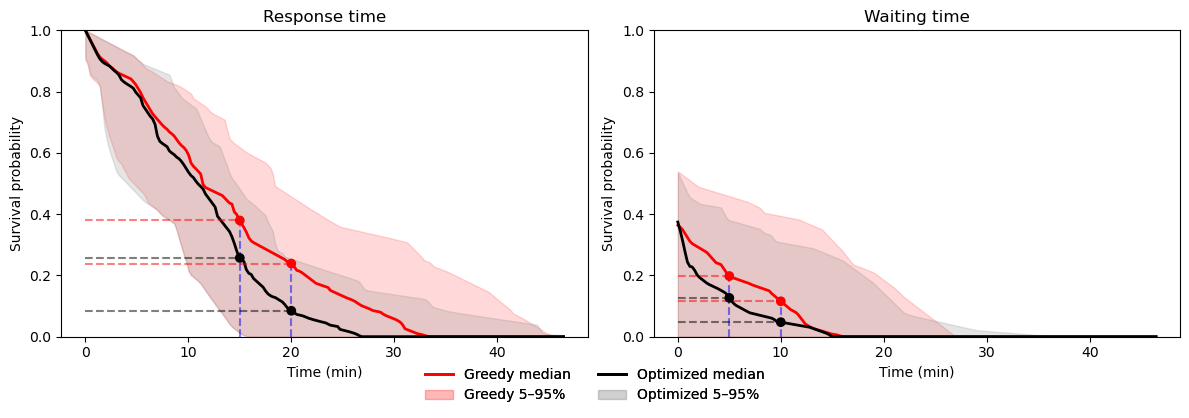

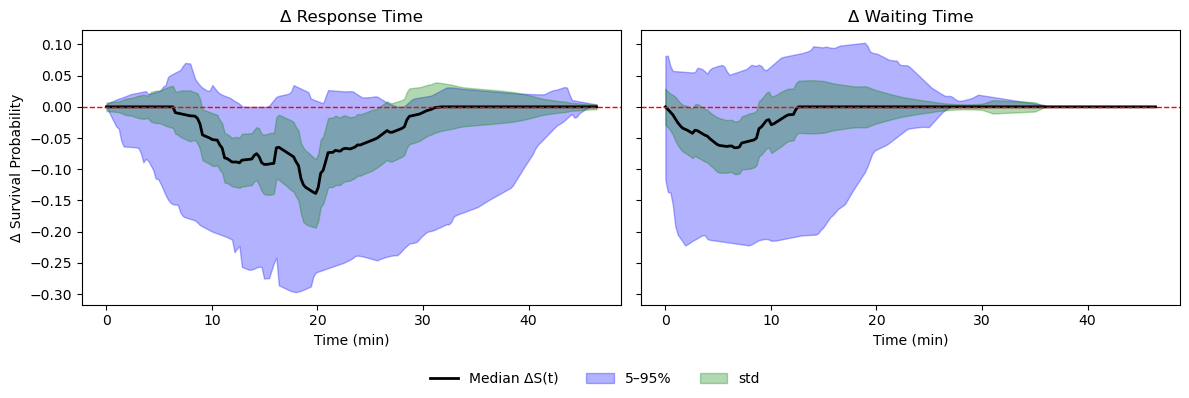

In [31]:
plt.figure(figsize=(12,4))

# ---------------- RT ----------------
ax1 = plt.subplot(1,2,1)
plot_band_compare(ax1, greedy_rt_curves, opt_rt_curves,
                  "Response time",
                  grid,
                  vlines=[15, 20])

# ---------------- WT ----------------
ax2 = plt.subplot(1,2,2)
plot_band_compare(ax2, greedy_wt_curves, opt_wt_curves,
                  "Waiting time",
                  grid,
                  vlines=[5,10])

plt.tight_layout()
plt.show()

plot_delta_survival(
    opt_rt_curves,
    greedy_rt_curves,
    opt_wt_curves,
    greedy_wt_curves,
    grid
)

### Interpretation of results
For the scenario with six hospitals, six ambulances, and a call arrival rate of 30 calls/h, the optimization policy shifts the response and waiting time distributions toward shorter values, representing an improvement in system's efficiency relative to the greedy policy. Specifically:

1) P(RT > 15 min) decreases from 37.9% to 25.7%, corresponding to a reduction of ~12 percentage points.
2) P(WT > 5 min) decreases from 19.8% to 12.7%, corresponding to an increase of ~7 percentage points.
3) The Δ survival curves show that the largest difference between policies occur around 15–20 minutes for response times, andaround 5 minutes for waiting times, indicating the time ranges where the effect of optimization is most pronounced.

The next step is to assess the system's response under different levels of stress, to achieve this we will vary the fleet size and will measure different performance metrics.

## 2. Sensitivity Analysis
To evaluate the effect of resource availability, the fleet size is varied according to:
$$
A \in {4,5,\ldots,10}.
$$
For each value of $A$, Monte Carlo simulations were conducted to estimate the empirical distributions of response time (RT) and waiting time (WT).

The performance shift was evaluated using delta survival curves $\Delta_A S(t)$. Analyzing this curves across different values of $A$ allows for the indentification of structural changes in central tendency, dispersion and intensity.  this approach quantifies global performance metrics via the Area Under the Curve $(AUC)$, detects peak regional improvements through the maximum benefit indicator $\Delta S_{min}(t)$, and evaluates operational reliability via tail probabilities. This comprehensive framework provides insights into how policy effectiveness scales across different resource constraints and temporal regimes.

In [9]:
amb_scenarios = [4, 5, 6, 7, 8, 9, 10]

all_greedy = []
all_opt = []

start = time.time()

for num_amb in amb_scenarios:

    print(f"\n==============================")
    print(f"Running scenario: {num_amb} ambulances")
    print(f"==============================")

    # 1. initialize ambulances for THIS scenario
    initial_ambulances = generate_ambulances(num_amb, city_limits, G)

    greedy_df, opt_df = monte_carlo_parallel(
        N_SIM=N,
        initial_ambulances=initial_ambulances,
        lamda=lamda,
        hospitals_precomputed=hospitals_precomputed,
        T=T,
        city_limits=city_limits
    )
    
    greedy_df["A"] = num_amb
    opt_df["A"] = num_amb

    all_opt.append(opt_df)
    all_greedy.append(greedy_df)

# merge everything
greedy_results = pd.concat(all_greedy, ignore_index=True)
opt_results = pd.concat(all_opt, ignore_index=True)

end = time.time()
print(f"\nTotal computing time: {(end - start)/60:.2f} minutes")


Running scenario: 4 ambulances
-----------------------------------------
Starting Parallel Monte Carlo (CRN)
-----------------------------------------


Simulando CRN: 100%|██████████| 30/30 [04:34<00:00,  9.16s/it]



Running scenario: 5 ambulances
-----------------------------------------
Starting Parallel Monte Carlo (CRN)
-----------------------------------------


Simulando CRN: 100%|██████████| 30/30 [05:05<00:00, 10.19s/it]



Running scenario: 6 ambulances
-----------------------------------------
Starting Parallel Monte Carlo (CRN)
-----------------------------------------


...


Running scenario: 9 ambulances
-----------------------------------------
Starting Parallel Monte Carlo (CRN)
-----------------------------------------


Simulando CRN: 100%|██████████| 30/30 [07:54<00:00, 15.82s/it]  



Running scenario: 10 ambulances
-----------------------------------------
Starting Parallel Monte Carlo (CRN)
-----------------------------------------


Simulando CRN: 100%|██████████| 30/30 [10:29<00:00, 21.00s/it]  


Total computing time: 123.82 minutes


## Performance plots
1) $ΔS(t)$ for different fleet sizes
2) Global benefit $(AUC)$: AUC values quantify the net reduction in cumulative system times achieved by the Optimal Policy (OP) relative to the Greedy Policy (GP). 
3) Maximum benefit $(ΔS(t)\ peak)$: The $\Delta S_{min}(t)$ metric captures the maximum localized advantage of implementing OP over GP. 
4) Tail probablity $P(T>t')$: The tail probability plots demonstrate the capacity of the optimal policy to mitigate extreme delays.

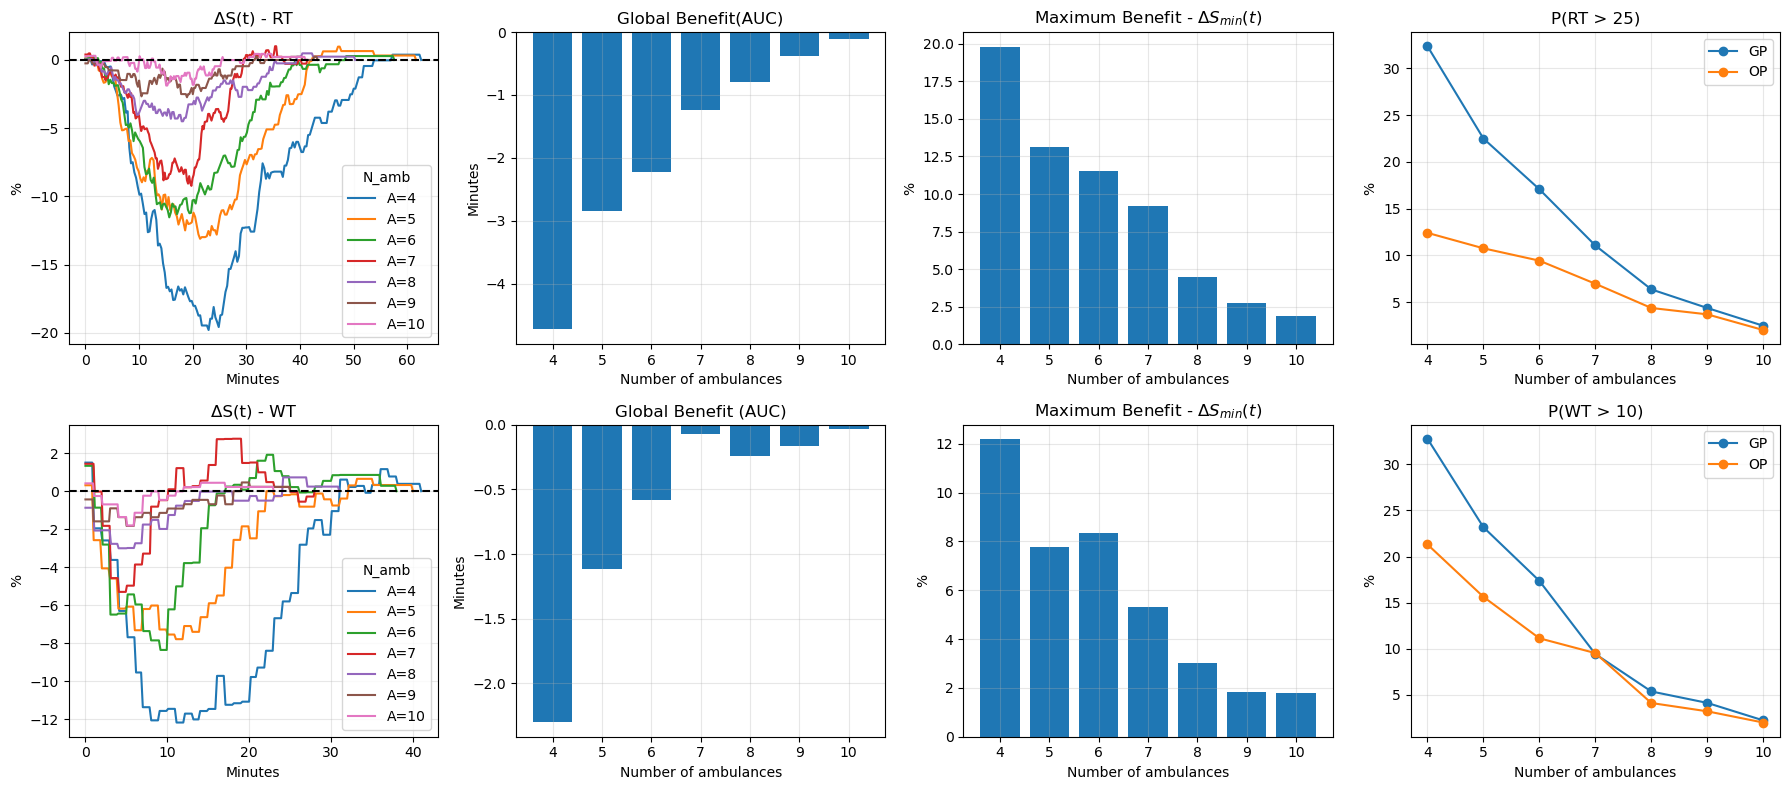

In [11]:
performance_plots(greedy_results,opt_results)

### Interpretation of results
1) **Distributional shifts in $\Delta S(t)$**: The delta survival distributions show a clear dampening in magnitud and compresion of their temporal span as the ambulance fleet increases. This behavior indicates that the operational gap between the two policies narrows when resources become abundant. An exception is observed for scenarios with 6 and 7 ambulances, where the distributions show an increased probability mass around waiting times of approximately 20 minutes, suggesting the precense of a transicional regime where available resources remain insufficient to absorve the demand.
2) **Global Benefits via AUC**: The overall benefit of the optimization policy decreases as ambulance availability increases, with the largest gains occurring when resources are scarce. When doubling the fleet size from 4 to 8 ambulances, the policy advantage declines by approximately 4 minutes in response time and 2 minutes in waiting time.
3) **Peak local benefits $\Delta S_{min}(t)$**: As expected, the most substantial gains are localized under high scarcity scenarios (4 ambulances), where strategic allocation is critical. Note that doubling the fleet size from 4 to 8 ambulances drops response time gains by ~15% and waiting time gains by ~9%.
4) **Tail probabilities and exceedence**: Both policies exhibit lower probabilities of long response and waiting times as ambulance availability increases. The greedy policy shows a steeper decline because it begins with substantially larger tail probabilities. In contrast, the optimized policy already reduces the occurrence of extreme delays under limited resources, leaving less room for further improvement. As a result, the marginal benefit of additional ambulances diminishes more quickly under the optimized policy, indicating that efficient allocation partially substitutes for increased fleet capacity. For instance, increasing the fleet size from 4 to 5 units reduces response time tail probabilities by ~10% under the greedy policy and ~3% under the optimazed policy. 

## Conclusion
The optimal policy provides the greatest benefit when resources are limited. As the number of ambulances increases, the performance of both policies asymptotically converges. This implies that while an optimal dispatch policy is critical under scarce resources, its added value decreases as more resources become available.